# Классические модели и сравнение с MLP

> Сорочан Дмитрий, [@legenda0008](https://t.me/legenda0008)

### Что делаю?

Сравниваю несколько простых классических моделей на тех же `20 000` train-объектах и тех же `10 000` validation-объектах, которые используются в architecture sweep.

Проверяю:
- Gaussian Naive Bayes;
- Logistic Regression;
- Random Forest.

Основные метрики -- `accuracy` и `macro-F1`, дополнительная -- `balanced accuracy`. Также сравниваю время обучения.

$\textcolor{red}{\#TODO}$ LGBM упал во время обучению, пофикшу и добавлю...

In [20]:
import gc
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
)
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from torchvision.datasets import FashionMNIST, MNIST


SEED = 143
CACHE_DIR = Path.home() / ".cache" / "mlstart_hw03"

PROJECT_DIR = Path("..") if Path.cwd().name == "notebooks" else Path(".")
REPORT_DIR = PROJECT_DIR / "report"
FIGURES_DIR = REPORT_DIR / "figures"
REPORT_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

VAL_SIZE = 10_000
TRAIN_SIZE = 20_000
MAX_ITER = 1_000



## Данные и валидация

Использую официальный `train` каждого датасета. Один раз делю его на train/validation со стратификацией и фиксированным `SEED`.

Чтобы сравнение с MLP было честным, классические модели обучаются на той же по размеру подвыборке `20 000`, что и основной architecture sweep.

In [21]:
def load_flat_data(dataset_class):
    dataset = dataset_class(CACHE_DIR, train=True, download=True)

    images = dataset.data.numpy().reshape(len(dataset), -1)
    y = dataset.targets.numpy()

    train_index, val_index = train_test_split(
        np.arange(len(y)),
        test_size=VAL_SIZE,
        stratify=y,
        random_state=SEED,
    )

    train_index, _ = train_test_split(
        train_index,
        train_size=TRAIN_SIZE,
        stratify=y[train_index],
        random_state=SEED,
    )

    X_train = images[train_index].astype(np.float32) / 255.0
    X_val = images[val_index].astype(np.float32) / 255.0
    y_train = y[train_index]
    y_val = y[val_index]

    del dataset, images, y
    gc.collect()

    return X_train, y_train, X_val, y_val


In [22]:
def get_models():
    return {
        "GaussianNB": GaussianNB(),
        "Logistic Regression": make_pipeline(
            StandardScaler(),
            LogisticRegression(
                solver="saga",
                max_iter=MAX_ITER,
                tol=1e-3,
                random_state=SEED,
            ),
        ),
        "Random Forest": RandomForestClassifier(
            n_estimators=200,
            min_samples_leaf=2,
            random_state=SEED,
            n_jobs=1,
        ),
    }


def evaluate_model(name, model, X_train, y_train, X_val, y_val):
    fitted_model = clone(model)

    started = time.perf_counter()
    fitted_model.fit(X_train, y_train)
    fit_time = time.perf_counter() - started

    predictions = fitted_model.predict(X_val)

    metrics = {
        "model": name,
        "accuracy": accuracy_score(y_val, predictions),
        "macro_f1": f1_score(y_val, predictions, average="macro"),
        "balanced_accuracy": balanced_accuracy_score(y_val, predictions),
        "fit_time_sec": fit_time,
    }

    del fitted_model
    gc.collect()

    return metrics, predictions


## MNIST

In [23]:
X_train, y_train, X_val, y_val = load_flat_data(MNIST)

mnist_results = []
mnist_predictions = {}

for name, model in get_models().items():
    print(name)

    metrics, predictions = evaluate_model(
        name,
        model,
        X_train,
        y_train,
        X_val,
        y_val,
    )

    mnist_results.append(metrics)
    mnist_predictions[name] = predictions

mnist_results = (
    pd.DataFrame(mnist_results)
    .sort_values("accuracy", ascending=False)
    .reset_index(drop=True)
)

mnist_results.to_csv(REPORT_DIR / "mnist_classical_results.csv", index=False)
mnist_results


GaussianNB
Logistic Regression
Random Forest


,model,accuracy,macro_f1,balanced_accuracy,fit_time_sec
0,Random Forest,0.9544,0.954000,0.954019,8.841288
1,Logistic Regression,0.9092,0.907918,0.908078,160.953757
2,GaussianNB,0.5589,0.507330,0.550695,0.036461


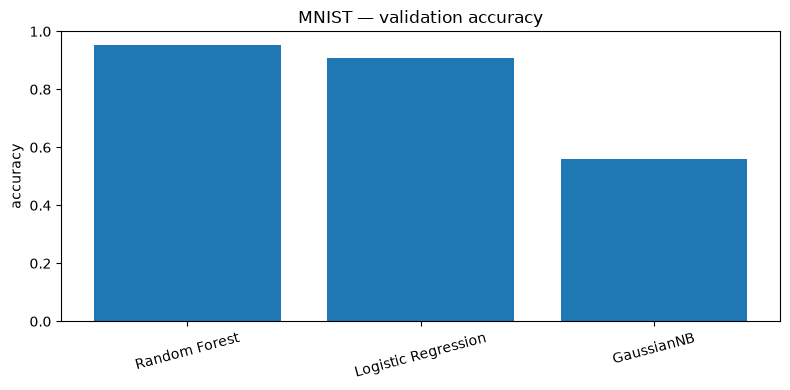

In [24]:
plt.figure(figsize=(8, 4))
plt.bar(mnist_results["model"], mnist_results["accuracy"])
plt.title("MNIST — validation accuracy")
plt.ylabel("accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "mnist_classical_accuracy.png", dpi=160)
plt.show()


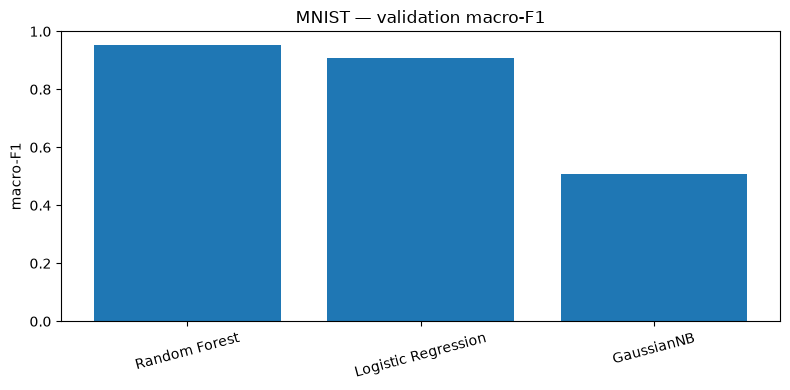

In [25]:
plt.figure(figsize=(8, 4))
plt.bar(mnist_results["model"], mnist_results["macro_f1"])
plt.title("MNIST — validation macro-F1")
plt.ylabel("macro-F1")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "mnist_classical_macro_f1.png", dpi=160)
plt.show()


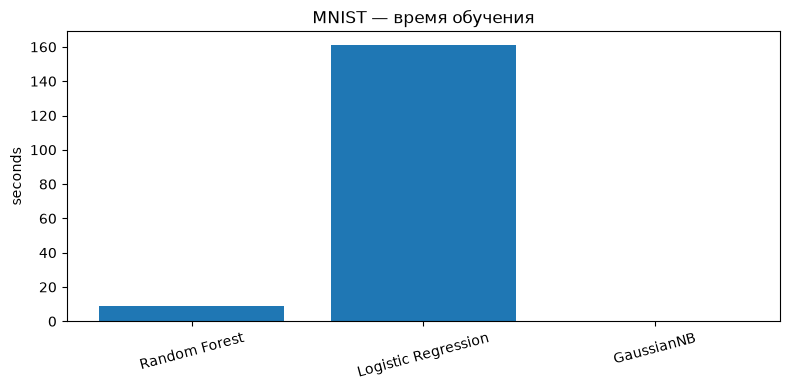

In [26]:
plt.figure(figsize=(8, 4))
plt.bar(mnist_results["model"], mnist_results["fit_time_sec"])
plt.title("MNIST — время обучения")
plt.ylabel("seconds")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "mnist_classical_fit_time.png", dpi=160)
plt.show()


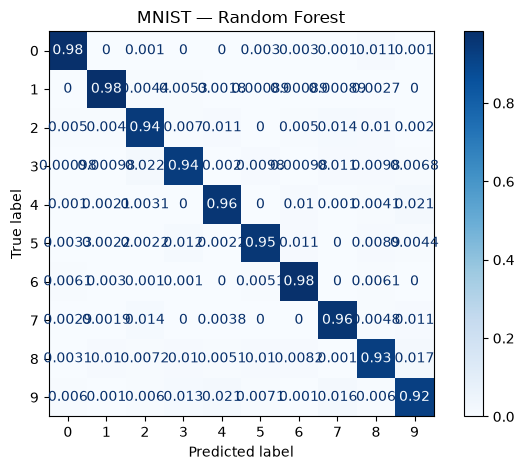

In [27]:
best_mnist_classic = mnist_results.iloc[0]["model"]

ConfusionMatrixDisplay.from_predictions(
    y_val,
    mnist_predictions[best_mnist_classic],
    cmap="Blues",
    normalize="true",
)

plt.title(f"MNIST — {best_mnist_classic}")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "mnist_best_classical_confusion_matrix.png", dpi=160)
plt.show()


In [28]:
del X_train, y_train, X_val, y_val, mnist_predictions
gc.collect()


19271

## Fashion-MNIST

In [29]:
X_train, y_train, X_val, y_val = load_flat_data(FashionMNIST)

fashion_results = []
fashion_predictions = {}

for name, model in get_models().items():
    print(name)

    metrics, predictions = evaluate_model(
        name,
        model,
        X_train,
        y_train,
        X_val,
        y_val,
    )

    fashion_results.append(metrics)
    fashion_predictions[name] = predictions

fashion_results = (
    pd.DataFrame(fashion_results)
    .sort_values("accuracy", ascending=False)
    .reset_index(drop=True)
)

fashion_results.to_csv(REPORT_DIR / "fashion_classical_results.csv", index=False)
fashion_results


GaussianNB
Logistic Regression
Random Forest


,model,accuracy,macro_f1,balanced_accuracy,fit_time_sec
0,Random Forest,0.8710,0.869739,0.8710,22.057144
1,Logistic Regression,0.8465,0.846219,0.8465,186.464056
2,GaussianNB,0.6125,0.583891,0.6125,0.026760


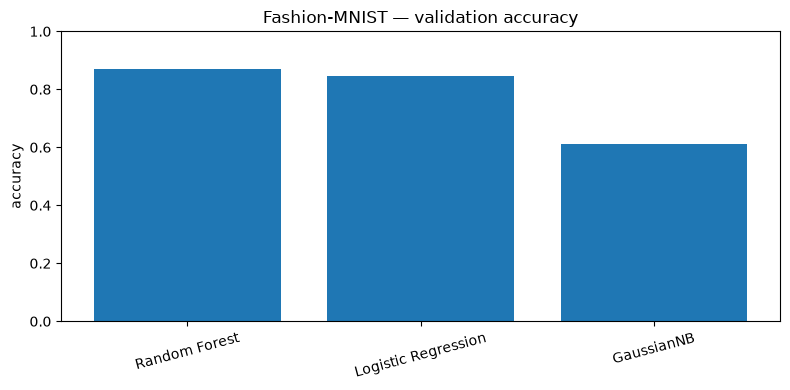

In [30]:
plt.figure(figsize=(8, 4))
plt.bar(fashion_results["model"], fashion_results["accuracy"])
plt.title("Fashion-MNIST — validation accuracy")
plt.ylabel("accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fashion_classical_accuracy.png", dpi=160)
plt.show()


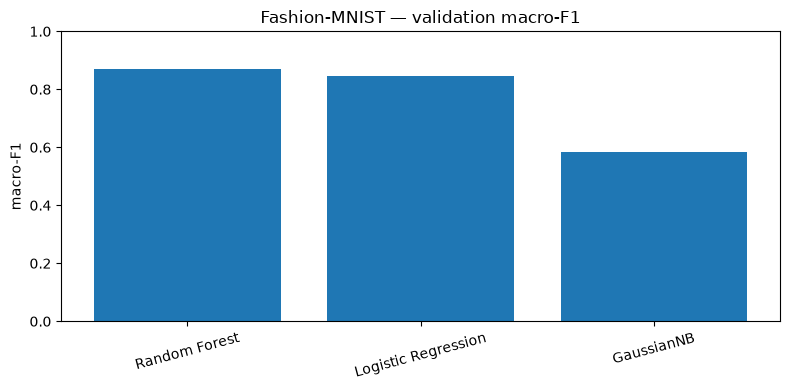

In [31]:
plt.figure(figsize=(8, 4))
plt.bar(fashion_results["model"], fashion_results["macro_f1"])
plt.title("Fashion-MNIST — validation macro-F1")
plt.ylabel("macro-F1")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fashion_classical_macro_f1.png", dpi=160)
plt.show()


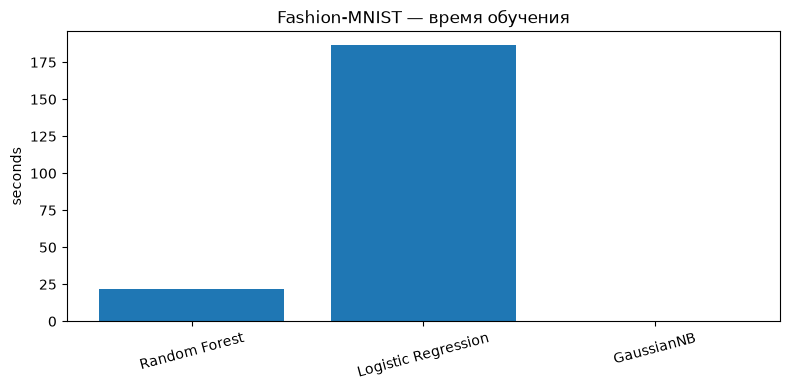

In [32]:
plt.figure(figsize=(8, 4))
plt.bar(fashion_results["model"], fashion_results["fit_time_sec"])
plt.title("Fashion-MNIST — время обучения")
plt.ylabel("seconds")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fashion_classical_fit_time.png", dpi=160)
plt.show()


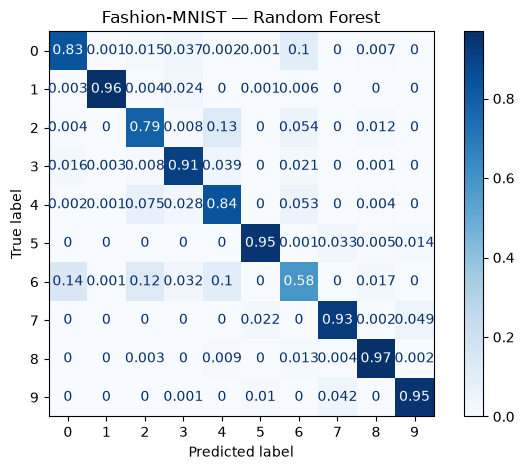

In [33]:
best_fashion_classic = fashion_results.iloc[0]["model"]

ConfusionMatrixDisplay.from_predictions(
    y_val,
    fashion_predictions[best_fashion_classic],
    cmap="Blues",
    normalize="true",
)

plt.title(f"Fashion-MNIST — {best_fashion_classic}")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fashion_best_classical_confusion_matrix.png", dpi=160)
plt.show()


In [34]:
del X_train, y_train, X_val, y_val, fashion_predictions
gc.collect()


19147

## Сравнение MLP и классики

[01_architecture_research.ipynb](/notebooks/01_architecture_research.ipynb) сохраняет результаты sweep в [report/*_architecture_results.csv](/notebooks/report/).


In [35]:
mnist_compare = mnist_results.rename(columns={
    "accuracy": "val_accuracy",
    "macro_f1": "val_macro_f1",
})[["model", "val_accuracy", "val_macro_f1", "fit_time_sec"]].copy()

fashion_compare = fashion_results.rename(columns={
    "accuracy": "val_accuracy",
    "macro_f1": "val_macro_f1",
})[["model", "val_accuracy", "val_macro_f1", "fit_time_sec"]].copy()

mnist_mlp_path = REPORT_DIR / "mnist_architecture_results.csv"
fashion_mlp_path = REPORT_DIR / "fashion_architecture_results.csv"

if mnist_mlp_path.exists():
    mnist_mlp = pd.read_csv(mnist_mlp_path)
    mnist_best_mlp = mnist_mlp.sort_values("val_accuracy", ascending=False).iloc[0]

    mnist_compare = pd.concat([
        mnist_compare,
        pd.DataFrame([{
            "model": f"MLP d={int(mnist_best_mlp.depth)}, w={int(mnist_best_mlp.width)}",
            "val_accuracy": mnist_best_mlp.val_accuracy,
            "val_macro_f1": mnist_best_mlp.val_macro_f1,
            "fit_time_sec": mnist_best_mlp.train_time_sec,
        }]),
    ], ignore_index=True)

if fashion_mlp_path.exists():
    fashion_mlp = pd.read_csv(fashion_mlp_path)
    fashion_best_mlp = fashion_mlp.sort_values("val_accuracy", ascending=False).iloc[0]

    fashion_compare = pd.concat([
        fashion_compare,
        pd.DataFrame([{
            "model": f"MLP d={int(fashion_best_mlp.depth)}, w={int(fashion_best_mlp.width)}",
            "val_accuracy": fashion_best_mlp.val_accuracy,
            "val_macro_f1": fashion_best_mlp.val_macro_f1,
            "fit_time_sec": fashion_best_mlp.train_time_sec,
        }]),
    ], ignore_index=True)

mnist_compare["dataset"] = "MNIST"
fashion_compare["dataset"] = "Fashion-MNIST"

model_comparison = pd.concat(
    [mnist_compare, fashion_compare],
    ignore_index=True,
)

model_comparison.to_csv(REPORT_DIR / "model_comparison.csv", index=False)
model_comparison


,model,val_accuracy,val_macro_f1,fit_time_sec,dataset
0,Random Forest,0.9544,0.954000,8.841288,MNIST
1,Logistic Regression,0.9092,0.907918,160.953757,MNIST
2,GaussianNB,0.5589,0.507330,0.036461,MNIST
3,Random Forest,0.8710,0.869739,22.057144,Fashion-MNIST
4,Logistic Regression,0.8465,0.846219,186.464056,Fashion-MNIST
5,GaussianNB,0.6125,0.583891,0.026760,Fashion-MNIST


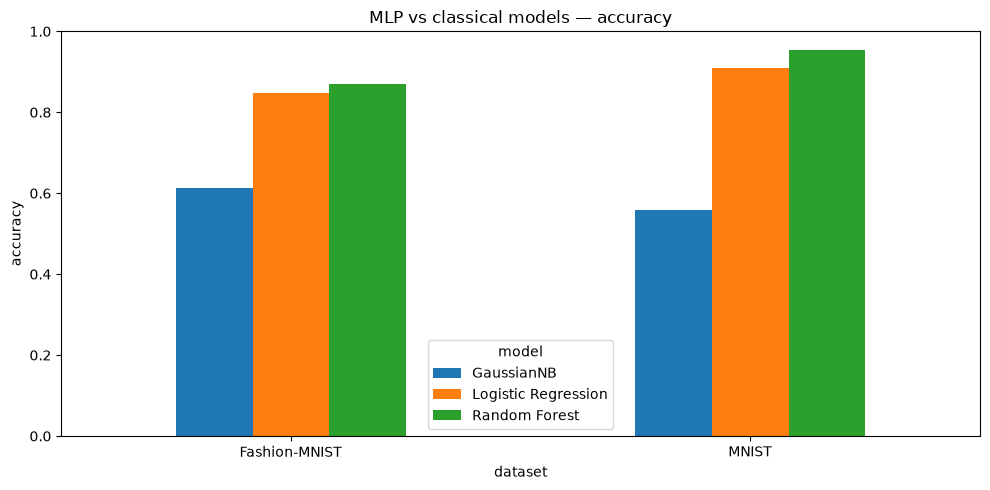

In [36]:
accuracy_table = model_comparison.pivot(
    index="dataset",
    columns="model",
    values="val_accuracy",
)

accuracy_table.plot(kind="bar", figsize=(10, 5))
plt.title("MLP vs classical models — accuracy")
plt.ylabel("accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "model_comparison_accuracy.png", dpi=160)
plt.show()


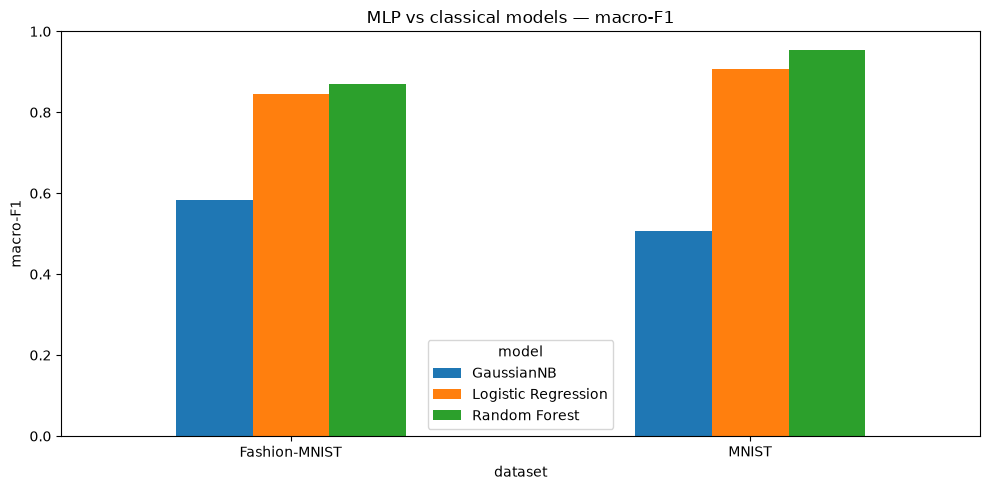

In [37]:
f1_table = model_comparison.pivot(
    index="dataset",
    columns="model",
    values="val_macro_f1",
)

f1_table.plot(kind="bar", figsize=(10, 5))
plt.title("MLP vs classical models — macro-F1")
plt.ylabel("macro-F1")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "model_comparison_macro_f1.png", dpi=160)
plt.show()


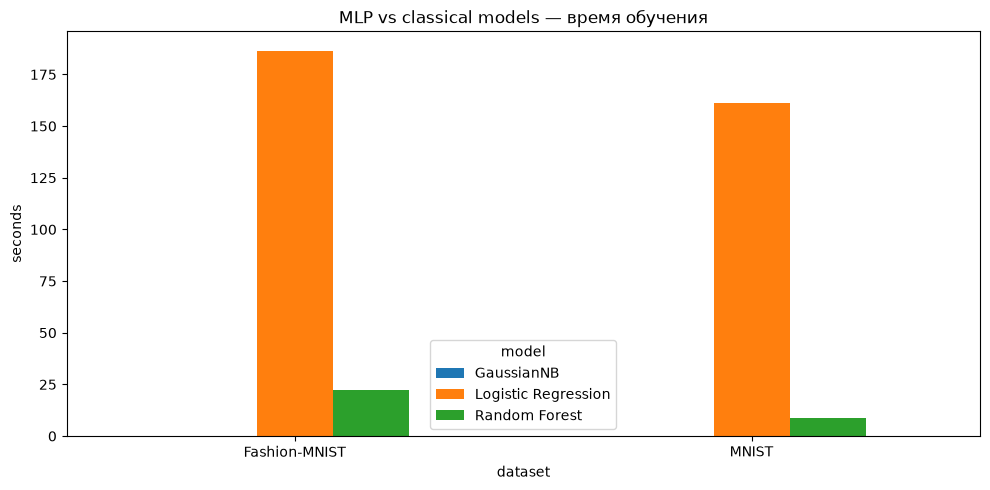

In [38]:
time_table = model_comparison.pivot(
    index="dataset",
    columns="model",
    values="fit_time_sec",
)

time_table.plot(kind="bar", figsize=(10, 5))
plt.title("MLP vs classical models — время обучения")
plt.ylabel("seconds")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "model_comparison_fit_time.png", dpi=160)
plt.show()


## Выводы

$\textcolor{red}{\#TODO}$ здесь -- сравнение классики и mlp неглубокого, но широкого (выбрать по ноутбуку 01 модели и их в коде в сравнение доабвить)
